In [211]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Poisson-distributed inputs at 5 Hz

- [ ] Does the neuron generate spikes? If so: what is their frequency and does it differ between TI / no TI conditions?
- [ ] TODO: 5 Hz stimulation with 1000 Hz carrier, with varying intensity.

## Example traces in a single cell (add to supplementary?)

In [340]:
cell_ids = np.arange(0, 20)

cell_id = 16
frequency = 5
carrier = 1000
beat = 5
amplitude = 0.9
filetype = "voltage.csv"

ti_9_filename = f"../output/temporal-interference-1/{cell_id}/random_poisson/{frequency}/{carrier}_{beat}_0.9_0.1/{filetype}"
ti_8_filename = f"../output/temporal-interference-1/{cell_id}/random_poisson/{frequency}/{carrier}_{beat}_0.8_0.1/{filetype}"
ti_7_filename = f"../output/temporal-interference-1/{cell_id}/random_poisson/{frequency}/{carrier}_{beat}_0.7_0.1/{filetype}"
ti_6_filename = f"../output/temporal-interference-1/{cell_id}/random_poisson/{frequency}/{carrier}_{beat}_0.6_0.1/{filetype}"
ti_5_filename = f"../output/temporal-interference-1/{cell_id}/random_poisson/{frequency}/{carrier}_{beat}_0.5_0.1/{filetype}"
noti_filename = f"../output/temporal-interference-1/{cell_id}/random_poisson/{frequency}/noTI_0.1/{filetype}"

ti_9 = pd.read_csv(ti_9_filename, index_col=0)
ti_8 = pd.read_csv(ti_8_filename, index_col=0)
ti_7 = pd.read_csv(ti_7_filename, index_col=0)
ti_6 = pd.read_csv(ti_6_filename, index_col=0)
ti_5 = pd.read_csv(ti_5_filename, index_col=0)
noti = pd.read_csv(noti_filename, index_col = 0)

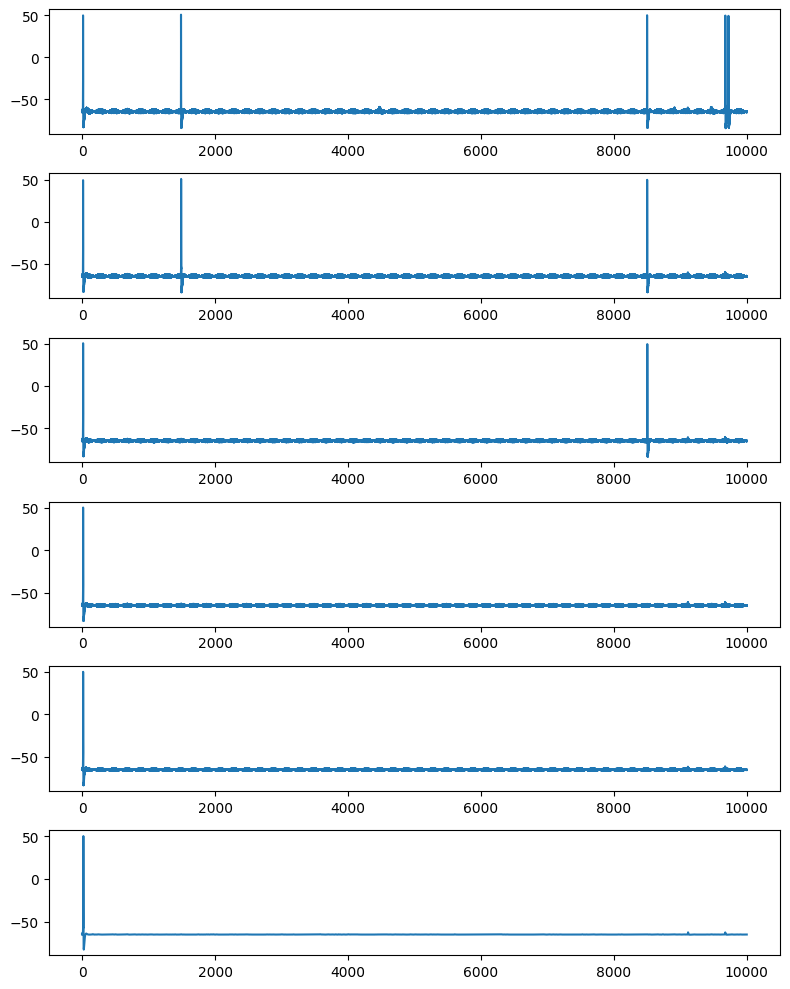

In [341]:
fig, axs = plt.subplots(nrows = 6, ncols = 1, figsize = (8, 10))

axs[0].plot(ti_9.Time, ti_9.Voltage)
axs[1].plot(ti_8.Time, ti_8.Voltage)
axs[2].plot(ti_7.Time, ti_7.Voltage)
axs[3].plot(ti_6.Time, ti_6.Voltage)
axs[4].plot(ti_5.Time, ti_5.Voltage)
axs[5].plot(noti.Time, noti.Voltage)

plt.tight_layout()
plt.show()

In [342]:
filetype = "synapse_weights.csv"

ti_9_filename = f"../output/temporal-interference-1/{cell_id}/random_poisson/{frequency}/{carrier}_{beat}_0.9_0.1/{filetype}"
ti_8_filename = f"../output/temporal-interference-1/{cell_id}/random_poisson/{frequency}/{carrier}_{beat}_0.8_0.1/{filetype}"
ti_7_filename = f"../output/temporal-interference-1/{cell_id}/random_poisson/{frequency}/{carrier}_{beat}_0.7_0.1/{filetype}"
ti_6_filename = f"../output/temporal-interference-1/{cell_id}/random_poisson/{frequency}/{carrier}_{beat}_0.6_0.1/{filetype}"
ti_5_filename = f"../output/temporal-interference-1/{cell_id}/random_poisson/{frequency}/{carrier}_{beat}_0.5_0.1/{filetype}"
noti_filename = f"../output/temporal-interference-1/{cell_id}/random_poisson/{frequency}/noTI_0.1/{filetype}"

ti_9 = pd.read_csv(ti_9_filename, index_col=0)
ti_8 = pd.read_csv(ti_8_filename, index_col=0)
ti_7 = pd.read_csv(ti_7_filename, index_col=0)
ti_6 = pd.read_csv(ti_6_filename, index_col=0)
ti_5 = pd.read_csv(ti_5_filename, index_col=0)
noti = pd.read_csv(noti_filename, index_col = 0)

In [343]:
synapse_cols = [f"Synapse{idx}" for idx in range(0, 10)]

ti_9_mean = ti_9[synapse_cols].to_numpy().mean(axis = 1)
ti_8_mean = ti_8[synapse_cols].to_numpy().mean(axis = 1)
ti_7_mean = ti_7[synapse_cols].to_numpy().mean(axis = 1)
ti_6_mean = ti_6[synapse_cols].to_numpy().mean(axis = 1)
ti_5_mean = ti_5[synapse_cols].to_numpy().mean(axis = 1)
noti_mean = noti[synapse_cols].to_numpy().mean(axis = 1)

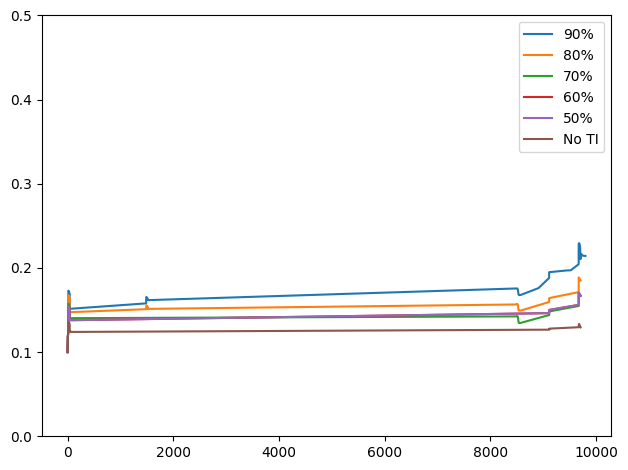

In [344]:
plt.plot(ti_9.Time, ti_9_mean, label = "90%")
plt.plot(ti_8.Time, ti_8_mean, label = "80%")
plt.plot(ti_7.Time, ti_7_mean, label = "70%")
plt.plot(ti_6.Time, ti_6_mean, label = "60%")
plt.plot(ti_5.Time, ti_6_mean, label = "50%")
plt.plot(noti.Time, noti_mean, label = "No TI")
plt.ylim(0, 0.5)
plt.legend()
plt.tight_layout()
plt.show()

## Average across configurations

To show:

- somatic firing frequency in different strengths (**expecting no difference** between no TI / TI conditions, starting at some stimulation strength)
- final weight distribution (**expecting a difference** in weight distribution, starting at some -- ideally the same -- stimulation strength)
- dendritic spiking frequency (**expecting a difference**)

In [345]:
cell_ids = np.arange(0, 20)
frequency = 5
carrier = 1000
beat = 5
amplitudes = [-1, 0.5, 0.6, 0.7, 0.8, 0.9]

In [346]:
# Somatic firing frequency

filetype = "spike_frequency.csv"

results = list()
for cell_id in cell_ids:
    for amplitude in amplitudes:
        if amplitude == -1:
            stim = "noTI"
        else:
            stim = f"{carrier}_{beat}_{amplitude}"
        
        filename = f"../output/temporal-interference-1/{cell_id}/random_poisson/{frequency}/{stim}_0.1/{filetype}"
        n_spikes = len(pd.read_csv(filename, index_col = 0))
        spike_freq = n_spikes / 10

        if amplitude == -1: amplitude = "No TI"
        else: amplitude = f"TI {round(amplitude * 100)}%"
        
        results.append(
            pd.DataFrame({
                "Amplitude": [amplitude],
                "Frequency": [spike_freq]
            })
        )

results = pd.concat(results)

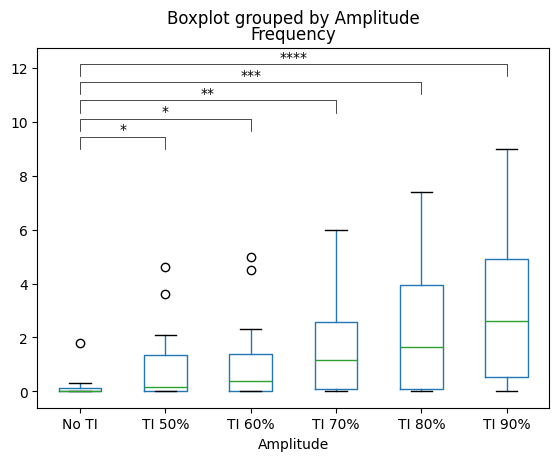

In [347]:
import matplotlib.pyplot as plt
import scipy.stats as stats

def p_to_stars(p):
    if p < 1e-4:
        return "****"
    elif p < 1e-3:
        return "***"
    elif p < 1e-2:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

# boxplot
ax = results.boxplot(column="Frequency", by="Amplitude")

# group data
grouped = list(results.groupby("Amplitude"))
labels = [name for name, _ in grouped]
groups = [g["Frequency"].values for _, g in grouped]

# find "No TI" index
ref_idx = labels.index("No TI")

y_max = results["Frequency"].max()
h = 0.05 * y_max
offset = 0

# compare "No TI" vs all others
for i in range(len(groups)):
    if i == ref_idx:
        continue

    stat, p_val = stats.ttest_ind(groups[ref_idx], groups[i])

    x1, x2 = ref_idx + 1, i + 1
    y = y_max + offset

    plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw = 0.5, color = "black")
    plt.text((x1 + x2) * 0.5, y + h, p_to_stars(p_val), ha="center", va="bottom")

    offset += h * 1.5

plt.grid(False)
plt.show()

In [348]:
# Final weight distributions (violin plots?)

filetype = "synapse_weights.csv"
synapse_cols = [f"Synapse{idx}" for idx in range(0, 10)]

results = list()
for cell_id in cell_ids:
    for amplitude in amplitudes:
        if amplitude == -1:
            stim = "noTI"
        else:
            stim = f"{carrier}_{beat}_{amplitude}"
        
        filename = f"../output/temporal-interference-1/{cell_id}/random_poisson/{frequency}/{stim}_0.1/{filetype}"
        synapse_weights = pd.read_csv(filename, index_col = 0)
        weights = synapse_weights[synapse_cols].iloc[-1].tolist()
        
        if amplitude == -1: amplitude = "No TI"
        else: amplitude = f"TI {round(amplitude * 100)}%"
        
        results.append(
            pd.DataFrame({
                "Amplitude": amplitude,
                "Weights": weights
            })
        )

results = pd.concat(results)

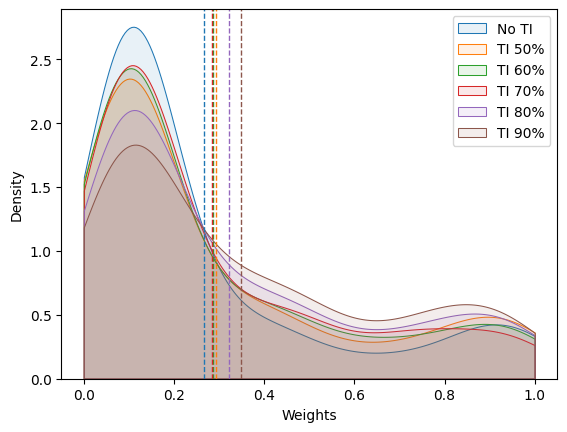

In [349]:
import seaborn as sns
import matplotlib.pyplot as plt

palette = sns.color_palette(n_colors=results["Amplitude"].nunique())

for (amplitude, group), color in zip(results.groupby("Amplitude"), palette):
    values = group["Weights"]

    sns.kdeplot(
        values,
        bw_adjust=1,
        clip=(0, 1),
        label=amplitude,
        fill=True,
        alpha=0.1,
        linewidth=0.75,
        color=color
    )

    mean_val = values.mean()
    plt.axvline(
        mean_val,
        linestyle="--",
        linewidth=1,
        color=color
    )

plt.legend()
plt.show()

In [350]:
filetype = "synapse_voltage.csv"

amplitude = amplitudes[1]

if amplitude == -1:
    stim = "noTI"
else:
    stim = f"{carrier}_{beat}_{amplitude}"

filename_dendrite = f"../output/temporal-interference-1/{cell_id}/random_poisson/{frequency}/{stim}_0.1/{filetype}"
filename_soma = f"../output/temporal-interference-1/{cell_id}/random_poisson/{frequency}/{stim}_0.1/voltage.csv"

synapse_voltage = pd.read_csv(filename_dendrite, index_col = 0)
soma_voltage = pd.read_csv(filename_soma, index_col = 0)

In [351]:
import numpy as np

def detect_dendritic_spikes(time, dend_v, soma_v, threshold=-20, refractory=2.0, window=2.0):
    above = dend_v >= threshold
    dend_cross_idx = np.where(np.diff(above.astype(int)) == 1)[0] + 1

    above = soma_v >= threshold
    soma_cross_idx = np.where(np.diff(above.astype(int)) == 1)[0] + 1

    if len(dend_cross_idx) == 0:
        return np.array([])

    dend_times = time[dend_cross_idx].to_numpy()
    soma_times = time[soma_cross_idx].to_numpy()

    valid = np.ones(len(dend_times), dtype=bool)

    # apply refractory (vectorized-ish)
    if refractory > 0:
        keep = []
        last_t = -np.inf
        for t in dend_times[valid]:
            if t - last_t > refractory:
                keep.append(True)
                last_t = t
            else:
                keep.append(False)
        valid_idx = np.where(valid)[0]
        valid[:] = False
        valid[valid_idx[np.array(keep)]] = True
    
    if len(soma_cross_idx) == 0:
        return dend_times[valid]

    # mark bAPs (soma spike within window before dend spike)
    # find nearest preceding soma spike for each dend spike
    idx = np.searchsorted(soma_times, dend_times, side="right") - 1

    has_prev = idx >= 0
    dt = np.full(len(dend_times), np.inf)
    dt[has_prev] = dend_times[has_prev] - soma_times[idx[has_prev]]

    is_bap = dt <= window
    valid &= ~is_bap

    return dend_times[valid]

In [352]:
results = list()
for cell_id in cell_ids:
    for amplitude in amplitudes:
        if amplitude == -1:
            stim = "noTI"
        else:
            stim = f"{carrier}_{beat}_{amplitude}"

        filename_dendrite = f"../output/temporal-interference-1/{cell_id}/random_poisson/{frequency}/{stim}_0.1/{filetype}"
        synapse_voltage = pd.read_csv(filename_dendrite, index_col = 0)
        
        filename_soma = f"../output/temporal-interference-1/{cell_id}/random_poisson/{frequency}/{stim}_0.1/voltage.csv"
        soma_voltage = pd.read_csv(filename_soma, index_col = 0)

        for synapse in synapse_cols:
            spikes = detect_dendritic_spikes(
                time = synapse_voltage.Time,
                dend_v = synapse_voltage[ synapse ],
                soma_v = soma_voltage.Voltage
            )

            if amplitude == -1: label = "No TI"
            else: label = f"TI {round(amplitude * 100)}%"

            results.append(
                pd.DataFrame({
                    "Frequency": [len(spikes) / 10],
                    "Amplitude": label
                })
            )

results = pd.concat(results)

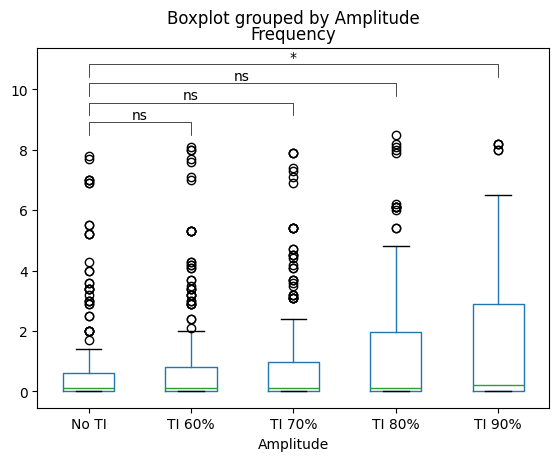

In [331]:
import matplotlib.pyplot as plt
import scipy.stats as stats

def p_to_stars(p):
    if p < 1e-4:
        return "****"
    elif p < 1e-3:
        return "***"
    elif p < 1e-2:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

# boxplot
ax = results.boxplot(column="Frequency", by="Amplitude")

# group data
grouped = list(results.groupby("Amplitude"))
labels = [name for name, _ in grouped]
groups = [g["Frequency"].values for _, g in grouped]

# find "No TI" index
ref_idx = labels.index("No TI")

y_max = results["Frequency"].max()
h = 0.05 * y_max
offset = 0

# compare "No TI" vs all others
for i in range(len(groups)):
    if i == ref_idx:
        continue

    stat, p_val = stats.ttest_ind(groups[ref_idx], groups[i])

    x1, x2 = ref_idx + 1, i + 1
    y = y_max + offset

    plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw = 0.5, color = "black")
    plt.text((x1 + x2) * 0.5, y + h, p_to_stars(p_val), ha="center", va="bottom")

    offset += h * 1.5

plt.grid(False)
plt.show()